In [2]:
from PIL import Image            #used to open preprocess images
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [8]:
#step1:load the image
img=Image.open(r"C:\Users\admin\Downloads\download.jpg")

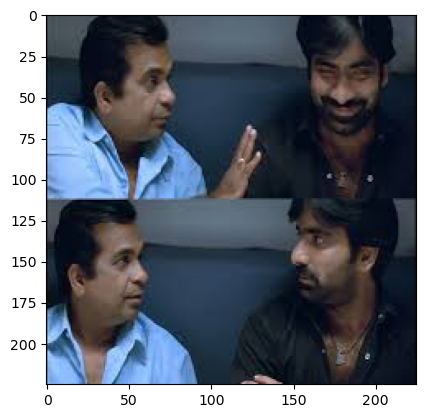

In [10]:
plt.imshow(img)

In [11]:
print("Original Image Size :",img.size)

Original Image Size : (225, 225)


In [12]:
img_rotate_90=img.rotate(90)


In [13]:
# Step:2 Basic Preprocessing 
processed= img.convert("RGB").resize((224,224))

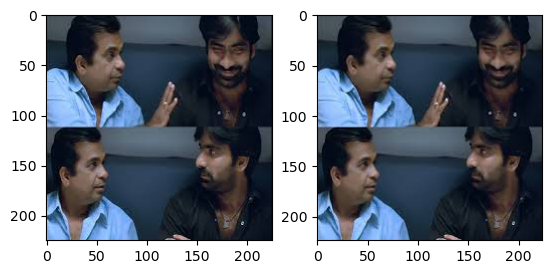

In [14]:
plt.subplot(1,2,1)
plt.imshow(img)

plt.subplot(1,2,2)
plt.imshow(processed)

In [15]:
img_array=np.array(processed).astype(np.float32)/255.0

In [16]:
# step:4: Flatten image pixels
flat_pixels=img_array.reshape(-1,3)   # -1 tells python to cal rows automatically 

In [17]:
#step:5 create pamdas Dataframe 

df=pd.DataFrame(flat_pixels,columns=['R','G','B'])

In [23]:
#step:6 Display Output
print(df.head())
print(df.shape)

          R         G         B
0  0.156863  0.200000  0.223529
1  0.290196  0.333333  0.356863
2  0.294118  0.337255  0.360784
3  0.274510  0.317647  0.341176
4  0.274510  0.317647  0.341176
(50176, 3)


# Multiple images 

In [24]:
import os

In [26]:
 img_folder=(r"C:\Users\admin\OneDrive\Pictures\Camera Roll")

In [27]:
# create emply list
data=[]

In [30]:
for img_name in os.listdir(img_folder):
    if img_name.lower().endswith((".jpg",".png",".jpeg")):
        img_path =os.path.join(img_folder,img_name)


        # load and process image 
        img=Image.open(img_path).convert("RGB").resize((224,224))
        img_array = np.array(img).astype(np.float32)/255.0


        #flatten pixels
        flat_pixels = img_array.reshape(-1,3)

        #Store each pixels as a row 
        for pixel in flat_pixels:
            data.append([img_name , pixel[0],pixel[1],pixel[2]])
            

In [32]:
# create a data frame
df=pd.DataFrame(data,columns=["image_name","R","G","B"])

In [33]:
print(df.head())
print(df.shape)

                     image_name         R         G         B
0  IMG_20260321_120907.jpg.jpeg  0.909804  0.921569  0.945098
1  IMG_20260321_120907.jpg.jpeg  0.913725  0.925490  0.952941
2  IMG_20260321_120907.jpg.jpeg  0.913725  0.929412  0.952941
3  IMG_20260321_120907.jpg.jpeg  0.913725  0.925490  0.952941
4  IMG_20260321_120907.jpg.jpeg  0.917647  0.933333  0.956863
(1655808, 4)


In [34]:
df

,image_name,R,G,B
0,IMG_20260321_120907.jpg.jpeg,0.909804,0.921569,0.945098
1,IMG_20260321_120907.jpg.jpeg,0.913725,0.925490,0.952941
2,IMG_20260321_120907.jpg.jpeg,0.913725,0.929412,0.952941
3,IMG_20260321_120907.jpg.jpeg,0.913725,0.925490,0.952941
4,IMG_20260321_120907.jpg.jpeg,0.917647,0.933333,0.956863
...,...,...,...,...
1655803,pro.jpeg,0.764706,0.568627,0.317647
1655804,pro.jpeg,0.756863,0.568627,0.321569
1655805,pro.jpeg,0.752941,0.568627,0.341176
1655806,pro.jpeg,0.756863,0.580392,0.376471
